In [1]:
# Install Required Libraries
%pip install tensorflow pandas matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

2026-05-06 20:32:40.245958: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-06 20:32:40.278955: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Create Sample Dataset

days = np.arange(1,121)

miles = (
    50
    + days * 0.8
    + 10 * np.sin(days/5)
    + np.random.normal(0,2,120)
)

data = pd.DataFrame({
    "Day": days,
    "Miles_Travelled": miles
})

# Save Dataset
data.to_csv("vehicle_miles.csv", index=False)

print(data.head())

   Day  Miles_Travelled
0    1        51.867114
1    2        56.570652
2    3        57.494068
3    4        59.597048
4    5        63.870855


In [3]:
# Load Dataset

data = pd.read_csv("vehicle_miles.csv")

print(data.head())

   Day  Miles_Travelled
0    1        51.867114
1    2        56.570652
2    3        57.494068
3    4        59.597048
4    5        63.870855


In [4]:
# Select Miles Column

miles_data = data.iloc[:,1].values.reshape(-1,1)

# Normalize Data
scaler = MinMaxScaler(feature_range=(0,1))

scaled_data = scaler.fit_transform(miles_data)

print(scaled_data[:5])

[[0.        ]
 [0.04939058]
 [0.05908712]
 [0.08116994]
 [0.12604802]]


In [5]:
# Create Dataset Function

def create_dataset(dataset, time_step=5):

    X, Y = [], []

    for i in range(len(dataset)-time_step-1):

        a = dataset[i:(i+time_step),0]

        X.append(a)

        Y.append(dataset[i + time_step,0])

    return np.array(X), np.array(Y)

# Create Sequences
time_step = 5

X, y = create_dataset(scaled_data, time_step)

print(X.shape)
print(y.shape)

(114, 5)
(114,)


In [6]:
# Reshape Data for RNN

X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape)

(114, 5, 1)


In [7]:
# Create RNN Model

model = Sequential()

model.add(SimpleRNN(
    50,
    activation='tanh',
    input_shape=(time_step,1)
))

model.add(Dense(1))

# Compile Model
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

# Display Model Summary
model.summary()

/opt/intel/oneapi/intelpython/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train Model

history = model.fit(
    X,
    y,
    epochs=50,
    batch_size=8,
    verbose=1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0162   
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0045 
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0038 
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0028 
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0028 
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0023 
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0020 
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0023 
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0025 
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0020 
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0018 
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0017 
Epoch 13/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0016 
Epoch 14/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0013     
Epoch 15/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0013

In [9]:
# Make Predictions

predictions = model.predict(X)

# Convert Back to Original Scale

predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(y.reshape(-1,1))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


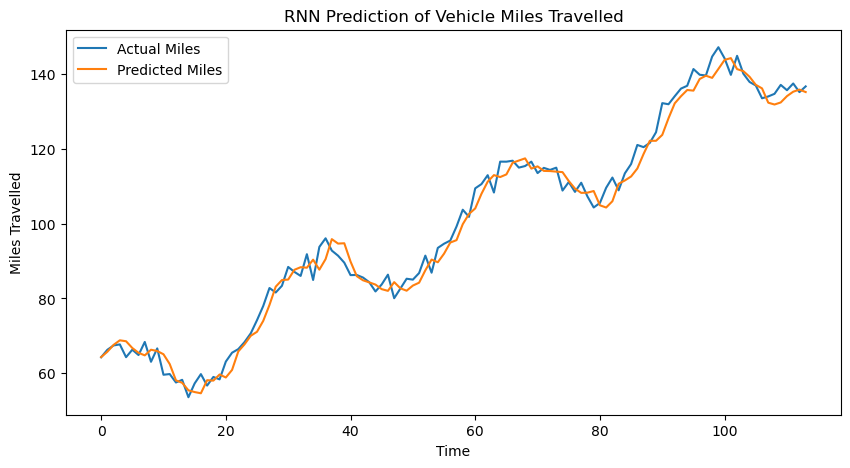

In [10]:
# Plot Results

plt.figure(figsize=(10,5))

plt.plot(actual, label="Actual Miles")

plt.plot(predictions, label="Predicted Miles")

plt.xlabel("Time")

plt.ylabel("Miles Travelled")

plt.title("RNN Prediction of Vehicle Miles Travelled")

plt.legend()

plt.show()